In [1]:
!pip install biopython


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from Bio import Entrez
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import time

# Always provide your email when using Entrez
Entrez.email = "user@example.com"

def get_pubmed_counts(term, start_year, end_year):
    counts = []
    for year in range(start_year, end_year + 1):
        # Search term structured as described in the methods
        search_query = f"({term}) AND ({year}[pdat])"
        try:
            # retmax=0 because we only need the Count metadata
            handle = Entrez.esearch(db="pubmed", term=search_query, retmax=0)
            record = Entrez.read(handle)
            handle.close()
            counts.append(int(record["Count"]))
        except Exception as e:
            print(f"Error fetching data for {year}: {e}")
            counts.append(0)
        # Respect NCBI rate limits (3 requests per second max without API key)
        time.sleep(0.35)
    return counts

In [3]:
NEURO_ONCOLOGY_QUERY = """
(
    ("Nervous System Neoplasms"[Mesh] OR "Paraneoplastic Syndromes, Nervous System"[Mesh])
    OR
    (
        "Glioblastoma" OR "Glioblastoma Multiforme" OR "Astrocytoma" OR "Oligodendroglioma"
        OR "Diffuse Midline Glioma" OR "H3 K27-altered" OR "Pilocytic Astrocytoma"
        OR "Pleomorphic Xanthoastrocytoma" OR "Subependymal Giant Cell Astrocytoma"
        OR "Ependymoma" OR "Myxopapillary ependymoma" OR "Ganglioglioma"
        OR "Dysembryoplastic Neuroepithelial Tumor" OR "DNET" OR "Central Neurocytoma"
        OR "Glioma" OR "DIPG" OR "Diffuse Midline Pontine Glioma" OR "Medulloblastoma"
        OR "Atypical Teratoid Rhabdoid Tumor" OR "Pineoblastoma" OR "Germinoma"
        OR "Meningioma" OR "Pituitary Adenoma" OR "Pituitary Neuroendocrine Tumor"
        OR "PNET" OR "Craniopharyngioma" OR "Vestibular Schwannoma" OR "Neurofibroma"
        OR "Brain Metastasis" OR "Brain Metastases" OR "Leptomeningeal Disease"
        OR "Leptomeningeal Carcinomatosis" OR "Primary CNS Lymphoma" OR "Hemangioblastoma"
        OR "Choroid Plexus Papilloma" OR "Paraneoplastic Neurological Syndrome"
        OR "Neurofibromatosis"
    )
)
""".strip()

GENERAL_NEUROSCIENCE_QUERY = """
(
    ("Nervous System Diseases"[Mesh] OR "Neurology"[Mesh] OR "Neurologic Manifestations"[Mesh])
    OR
    (
        "Stroke" OR "Cerebrovascular Accident" OR "CVA" OR "Ischemic Stroke"
        OR "Intracerebral Hemorrhage" OR "Hemorrhagic Stroke" OR "Subarachnoid Hemorrhage"
        OR "Transient Ischemic Attack" OR "TIA" OR "Cerebral Aneurysm"
        OR "Arteriovenous Malformation" OR "AVM" OR "Cavernous Angioma" OR "Cavernoma"
        OR "Moyamoya Disease" OR "Cerebral Venous Sinus Thrombosis" OR "Alzheimer Disease"
        OR "Alzheimer's Disease" OR "Parkinson Disease" OR "Parkinson's Disease"
        OR "Amyotrophic Lateral Sclerosis" OR "ALS" OR "Frontotemporal Dementia"
        OR "Frontotemporal Lobar Degeneration" OR "Lewy Body Dementia"
        OR "Dementia with Lewy Bodies" OR "Huntington Disease" OR "Huntington's Disease"
        OR "Creutzfeldt-Jakob Disease" OR "Prion Disease" OR "Corticobasal Degeneration"
        OR "Multiple System Atrophy" OR "Shy-Drager Syndrome" OR "Progressive Supranuclear Palsy"
        OR "Multiple Sclerosis" OR "Relapsing-Remitting MS" OR "Neuromyelitis Optica"
        OR "NMO" OR "Devic's Disease" OR "MOG Antibody Disease" OR "MOGAD"
        OR "Acute Disseminated Encephalomyelitis" OR "ADEM"
        OR "Anti-NMDA Receptor Encephalitis" OR "Autoimmune Encephalitis"
        OR "Stiff-Person Syndrome" OR "Epilepsy" OR "Seizure Disorder"
        OR "Status Epilepticus" OR "Temporal Lobe Epilepsy" OR "Lennox-Gastaut Syndrome"
        OR "Dravet Syndrome" OR "West Syndrome" OR "Infantile Spasms"
        OR "Migraine Disorders" OR "Migraine" OR "Cluster Headache" OR "Trigeminal Neuralgia"
        OR "Idiopathic Intracranial Hypertension" OR "Pseudotumor Cerebri"
        OR "Myasthenia Gravis" OR "Guillain-Barre Syndrome" OR "GBS"
        OR "Chronic Inflammatory Demyelinating Polyneuropathy" OR "CIDP"
        OR "Lambert-Eaton Myasthenic Syndrome" OR "Charcot-Marie-Tooth Disease"
        OR "Duchenne Muscular Dystrophy" OR "Spinal Muscular Atrophy" OR "SMA"
        OR "Complex Regional Pain Syndrome" OR "CRPS" OR "Essential Tremor" OR "Dystonia"
        OR "Cervical Dystonia" OR "Tourette Syndrome" OR "Restless Legs Syndrome"
        OR "Ataxia" OR "Spinocerebellar Ataxia" OR "Friedreich Ataxia" OR "Wilson Disease"
        OR "Meningitis" OR "Encephalitis" OR "Brain Abscess" OR "Neurosyphilis"
        OR "Traumatic Brain Injury" OR "TBI" OR "Chronic Traumatic Encephalopathy"
        OR "CTE" OR "Concussion" OR "Spinal Cord Injury" OR "Hydrocephalus"
        OR "Normal Pressure Hydrocephalus" OR "NPH" OR "Chiari Malformation"
        OR "Spina Bifida" OR "Myelomeningocele" OR "Syringomyelia"
    )
)
""".strip()

start_year = 2000
end_year = 2025
years = list(range(start_year, end_year + 1))

print("Fetching general neuroscience publications...")
general_neuroscience_counts = get_pubmed_counts(GENERAL_NEUROSCIENCE_QUERY, start_year, end_year)

print("Fetching neuro-oncology publications...")
neuro_oncology_counts = get_pubmed_counts(NEURO_ONCOLOGY_QUERY, start_year, end_year)

df_pubs = pd.DataFrame({
    "Year": years,
    "General neuroscience": general_neuroscience_counts,
    "Neuro-oncology": neuro_oncology_counts,
})

df_pubs["Neuro-oncology proportion"] = (
    df_pubs["Neuro-oncology"] / df_pubs["General neuroscience"]
)

display(df_pubs.head())

Fetching general neuroscience publications...


Fetching neuro-oncology publications...


,Year,General neuroscience,Neuro-oncology,Neuro-oncology proportion
0,2000,60889,5601,0.091987
1,2001,62557,5517,0.088192
2,2002,64356,5412,0.084095
3,2003,69084,5889,0.085244
4,2004,74309,6089,0.081942


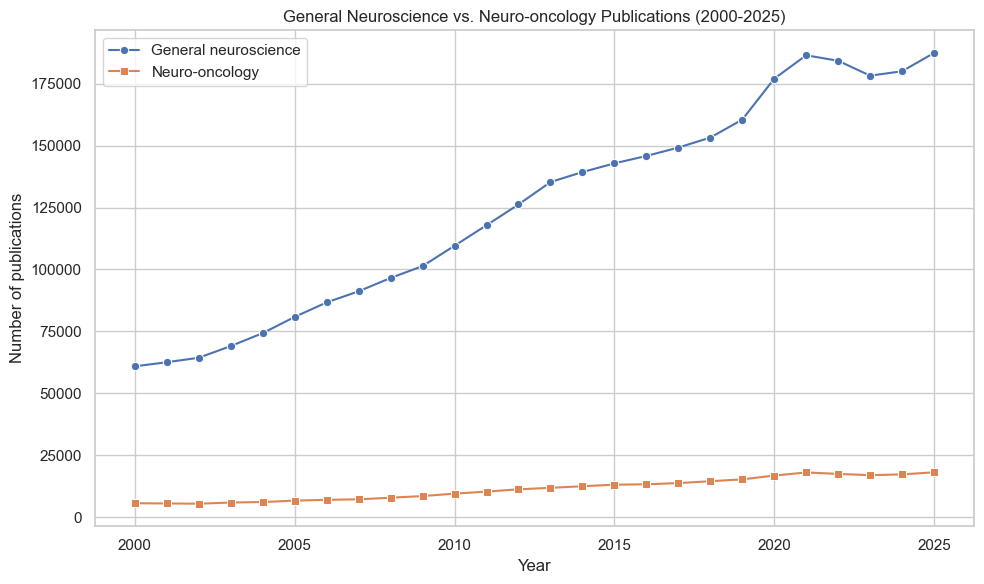

In [4]:
# Set seaborn style
sns.set_theme(style="whitegrid")

# Plot 1: General neuroscience vs. neuro-oncology
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pubs, x="Year", y="General neuroscience", label="General neuroscience", marker="o")
sns.lineplot(data=df_pubs, x="Year", y="Neuro-oncology", label="Neuro-oncology", marker="s")
plt.title("General Neuroscience vs. Neuro-oncology Publications (2000-2025)")
plt.ylabel("Number of publications")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

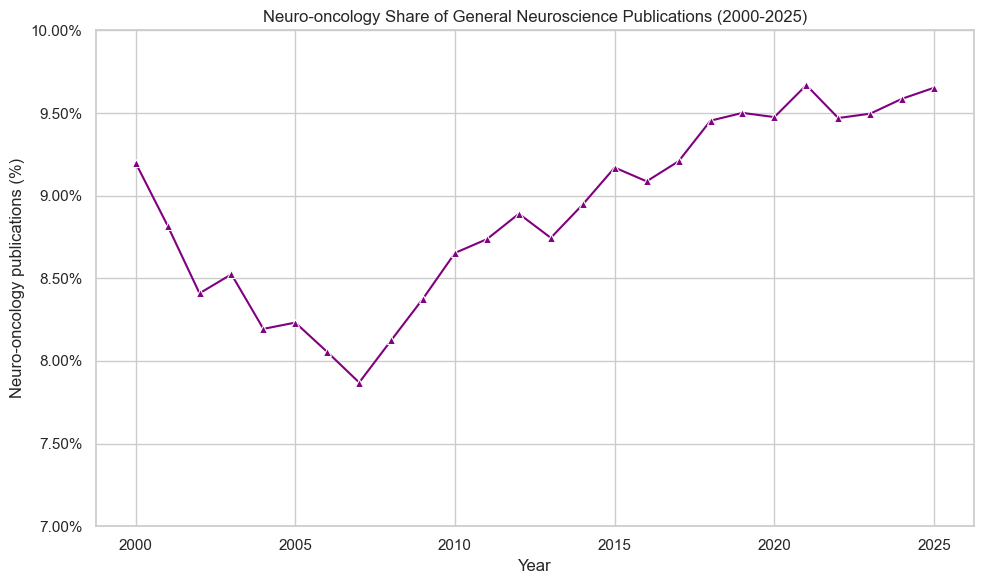

In [5]:
# Plot 2: Neuro-oncology as a proportion of general neuroscience
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pubs, x="Year", y="Neuro-oncology proportion", color="purple", marker="^")
plt.title("Neuro-oncology Share of General Neuroscience Publications (2000-2025)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.ylim(0.07, 0.10)
plt.ylabel("Neuro-oncology publications (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

## Chemotherapy-related neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records matching the specified neuro-oncology disease terms and chemotherapy terms across completed calendar years.

https://pmc.ncbi.nlm.nih.gov/articles/PMC9140894/
https://www.frontiersin.org/journals/neurology/articles/10.3389/fneur.2025.1606149/full
https://pmc.ncbi.nlm.nih.gov/articles/PMC13013171/
https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1287725/full

In [6]:
CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY = """
(
    "Glioblastoma" OR "Glioblastoma Multiforme" OR "Astrocytoma" OR "Oligodendroglioma"
    OR "Diffuse Midline Glioma" OR "H3 K27-altered" OR "Pilocytic Astrocytoma"
    OR "Pleomorphic Xanthoastrocytoma" OR "Subependymal Giant Cell Astrocytoma"
    OR "Ependymoma" OR "Myxopapillary ependymoma" OR "Ganglioglioma"
    OR "Dysembryoplastic Neuroepithelial Tumor" OR "DNET" OR "Central Neurocytoma"
    OR "Glioma" OR "DIPG" OR "Diffuse Midline Pontine Glioma" OR "Medulloblastoma"
    OR "Atypical Teratoid Rhabdoid Tumor" OR "Pineoblastoma" OR "Germinoma"
    OR "Meningioma" OR "Pituitary Adenoma" OR "Pituitary Neuroendocrine Tumor"
    OR "PNET" OR "Craniopharyngioma" OR "Vestibular Schwannoma" OR "Neurofibroma"
    OR "Brain Metastasis" OR "Brain Metastases" OR "Leptomeningeal Disease"
    OR "Leptomeningeal Carcinomatosis" OR "Primary CNS Lymphoma" OR "Hemangioblastoma"
    OR "Choroid Plexus Papilloma" OR "Paraneoplastic Neurological Syndrome"
    OR "Neurofibromatosis"
)
AND
(
    "Chemotherapy" OR "Chemotherapeutic" OR "Chemotherapeutic Agents"
    OR "Cytotoxic Chemotherapy" OR "Antineoplastic Agents"
    OR "Alkylating Agent" OR "Alkylating Agents"
    OR "Nitrosourea" OR "Nitrosoureas" OR "Chloroethyl Nitrosourea"

    OR "Temozolomide" OR "TMZ"

    OR "Lomustine" OR "CCNU" OR "Carmustine" OR "BCNU" OR "Fotemustine"

    OR "Procarbazine" OR "Vincristine" OR "PCV"

    OR "Carboplatin" OR "Vinblastine" OR "Thioguanine" OR "TPCV" OR "Etoposide"

    OR "Cisplatin" OR "Cyclophosphamide"

    OR "Pemetrexed" OR "Capecitabine" OR "Eribulin"
    OR "Anthracycline" OR "Anthracyclines"

    OR "Irinotecan"
)
""".strip()

chemotherapy_start_year = 2000
chemotherapy_end_year = 2025
chemotherapy_years = list(range(chemotherapy_start_year, chemotherapy_end_year + 1))

print("Fetching chemotherapy-related neuro-oncology publications...")
chemotherapy_counts = get_pubmed_counts(
    CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY,
    chemotherapy_start_year,
    chemotherapy_end_year,
)

chemotherapy_trend = pd.DataFrame({
    "Year": chemotherapy_years,
    "Publications": chemotherapy_counts,
})
chemotherapy_trend["Year-over-year change (%)"] = (
    chemotherapy_trend["Publications"].pct_change() * 100
)
chemotherapy_trend["3-year rolling average"] = (
    chemotherapy_trend["Publications"].rolling(window=3, min_periods=3)
    .mean()
)

display(chemotherapy_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching chemotherapy-related neuro-oncology publications...


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,610,NaN,NaN
1,2001,589,-3.4,NaN
2,2002,596,1.2,598.3
3,2003,676,13.4,620.3
4,2004,745,10.2,672.3
5,2005,799,7.2,740.0
6,2006,920,15.1,821.3
7,2007,1001,8.8,906.7
8,2008,1162,16.1,1027.7
9,2009,1306,12.4,1156.3


In [7]:
complete_chemotherapy_years = chemotherapy_trend[chemotherapy_trend["Year"] <= 2025]
first_row = complete_chemotherapy_years.iloc[0]
last_row = complete_chemotherapy_years.iloc[-1]
peak_row = complete_chemotherapy_years.loc[complete_chemotherapy_years["Publications"].idxmax()]
year_span = int(last_row["Year"] - first_row["Year"])
overall_change = (last_row["Publications"] / first_row["Publications"] - 1) * 100
cagr = (last_row["Publications"] / first_row["Publications"]) ** (1 / year_span) - 1
chemotherapy_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(first_row['Publications']):,}",
        f"{int(last_row['Publications']):,}",
        f"{int(last_row['Publications'] - first_row['Publications']):,}",
        f"{overall_change:.1f}%",
        f"{cagr:.1%}",
        f"{int(peak_row['Year'])}",
        f"{int(peak_row['Publications']):,}",
    ],
})
display(chemotherapy_summary)

,Metric,Value
0,Publications in 2000,610
1,Publications in 2025 (last complete year),"2,976"
2,"Absolute increase, 2000–2025","2,366"
3,"Percentage increase, 2000–2025",387.9%
4,"Compound annual growth rate, 2000–2025",6.5%
5,Peak complete year,2025
6,Publications in peak complete year,"2,976"


## Small-molecule and targeted-therapy neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records that match the same neuro-oncology disease context used above and at least one of the specified targeted-therapy, inhibitor-class, or named small-molecule terms.

In [8]:
SMALL_MOLECULE_TARGETED_THERAPY_QUERY = """
(
    "Targeted Therapy" OR "Targeted Therapies"
    OR "Molecularly Targeted Therapy" OR "Molecular Targeted Therapy"
    OR "Small Molecule Inhibitor" OR "Small Molecule Inhibitors"
    OR "Tyrosine Kinase Inhibitor" OR "Tyrosine Kinase Inhibitors" OR "TKI" OR "TKIs"

    OR "EGFR Inhibitor" OR "EGFR Inhibitors"
    OR "Erlotinib" OR "Gefitinib" OR "Afatinib" OR "Dacomitinib"
    OR "Osimertinib" OR "BDTX-1535" OR "WSD0922"

    OR "VEGFR Inhibitor" OR "VEGFR Inhibitors"
    OR "Axitinib" OR "Cediranib" OR "Vatalanib" OR "PTK787" OR "Apatinib"

    OR "PDGFR Inhibitor" OR "PDGFR Inhibitors" OR "Imatinib"

    OR "BRAF Inhibitor" OR "BRAF Inhibitors" OR "RAF Inhibitor" OR "RAF Inhibitors"
    OR "Vemurafenib" OR "Dabrafenib" OR "Encorafenib" OR "Tovorafenib"
    OR "Plixorafenib" OR "PLX8394"

    OR "MEK Inhibitor" OR "MEK Inhibitors"
    OR "Trametinib" OR "Selumetinib" OR "Binimetinib" OR "Cobimetinib"

    OR "IDH Inhibitor" OR "IDH Inhibitors" OR "IDH1 Inhibitor" OR "IDH2 Inhibitor"
    OR "Mutant IDH Inhibitor" OR "Vorasidenib" OR "AG-881" OR "Ivosidenib"
    OR "Safusidenib" OR "Olutasidenib" OR "FT-2102" OR "DS-1001"
    OR "BAY 1436032" OR "MRK-A"

    OR "NTRK Inhibitor" OR "NTRK Inhibitors" OR "TRK Inhibitor" OR "TRK Inhibitors"
    OR "Larotrectinib" OR "Entrectinib"

    OR "ALK Inhibitor" OR "ALK Inhibitors"
    OR "Alectinib" OR "Ceritinib" OR "Brigatinib" OR "Lorlatinib" OR "Crizotinib"

    OR "ROS1 Inhibitor" OR "ROS1 Inhibitors"

    OR "MET Inhibitor" OR "MET Inhibitors" OR "Capmatinib" OR "Tepotinib"

    OR "RET Inhibitor" OR "RET Inhibitors" OR "Selpercatinib" OR "Pralsetinib"

    OR "KRAS Inhibitor" OR "KRAS G12C Inhibitor" OR "Sotorasib"

    OR "HER2 Inhibitor" OR "HER2 Inhibitors"
    OR "Lapatinib" OR "Neratinib" OR "Tucatinib"

    OR "CDK4/6 Inhibitor" OR "CDK4/6 Inhibitors" OR "Abemaciclib"

    OR "PI3K Inhibitor" OR "PI3K Inhibitors" OR "Alpelisib"

    OR "mTOR Inhibitor" OR "mTOR Inhibitors" OR "Everolimus" OR "Temsirolimus"

    OR "PARP Inhibitor" OR "PARP Inhibitors" OR "Olaparib"

    OR "Farnesyl Transferase Inhibitor" OR "Farnesyl Transferase Inhibitors"
    OR "Tipifarnib" OR "Lonafarnib"

    OR "HDAC Inhibitor" OR "HDAC Inhibitors" OR "Vorinostat" OR "Romidepsin"

    OR "Integrin Inhibitor" OR "Integrin Inhibitors" OR "Cilengitide"

    OR "Dordaviprone" OR "ONC201"

    OR "MCT Inhibitor" OR "MCT Inhibitors"
)
""".strip()

NEURO_ONCOLOGY_DISEASE_CONTEXT = CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY.split("\nAND\n", 1)[0]
SMALL_MOLECULE_NEURO_ONCOLOGY_QUERY = (
    f"{NEURO_ONCOLOGY_DISEASE_CONTEXT}\nAND\n{SMALL_MOLECULE_TARGETED_THERAPY_QUERY}"
)

small_molecule_start_year = 2000
small_molecule_end_year = 2025
small_molecule_years = list(range(small_molecule_start_year, small_molecule_end_year + 1))

print("Fetching small-molecule and targeted-therapy neuro-oncology publications...")
small_molecule_counts = get_pubmed_counts(
    SMALL_MOLECULE_NEURO_ONCOLOGY_QUERY,
    small_molecule_start_year,
    small_molecule_end_year,
)

small_molecule_trend = pd.DataFrame({
    "Year": small_molecule_years,
    "Publications": small_molecule_counts,
})
small_molecule_trend["Year-over-year change (%)"] = (
    small_molecule_trend["Publications"].pct_change() * 100
)
small_molecule_trend["3-year rolling average"] = (
    small_molecule_trend["Publications"].rolling(window=3, min_periods=3).mean()
)

display(small_molecule_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching small-molecule and targeted-therapy neuro-oncology publications...


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,15,NaN,NaN
1,2001,25,66.7,NaN
2,2002,33,32.0,24.3
3,2003,45,36.4,34.3
4,2004,73,62.2,50.3
5,2005,98,34.2,72.0
6,2006,148,51.0,106.3
7,2007,150,1.4,132.0
8,2008,181,20.7,159.7
9,2009,239,32.0,190.0


In [9]:
complete_small_molecule_years = small_molecule_trend[small_molecule_trend["Year"] <= 2025]
small_molecule_first_row = complete_small_molecule_years.iloc[0]
small_molecule_last_row = complete_small_molecule_years.iloc[-1]
small_molecule_peak_row = complete_small_molecule_years.loc[
    complete_small_molecule_years["Publications"].idxmax()
]
small_molecule_year_span = int(
    small_molecule_last_row["Year"] - small_molecule_first_row["Year"]
)
small_molecule_overall_change = (
    small_molecule_last_row["Publications"] / small_molecule_first_row["Publications"] - 1
) * 100
small_molecule_cagr = (
    small_molecule_last_row["Publications"] / small_molecule_first_row["Publications"]
) ** (1 / small_molecule_year_span) - 1

small_molecule_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(small_molecule_first_row['Publications']):,}",
        f"{int(small_molecule_last_row['Publications']):,}",
        f"{int(small_molecule_last_row['Publications'] - small_molecule_first_row['Publications']):,}",
        f"{small_molecule_overall_change:.1f}%",
        f"{small_molecule_cagr:.1%}",
        f"{int(small_molecule_peak_row['Year'])}",
        f"{int(small_molecule_peak_row['Publications']):,}",
    ],
})
display(small_molecule_summary)

,Metric,Value
0,Publications in 2000,15
1,Publications in 2025 (last complete year),"1,508"
2,"Absolute increase, 2000–2025","1,493"
3,"Percentage increase, 2000–2025",9953.3%
4,"Compound annual growth rate, 2000–2025",20.3%
5,Peak complete year,2025
6,Publications in peak complete year,"1,508"


## Antibody and antibody-drug conjugate neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records that match the same neuro-oncology disease context and at least one of the specified antibody or antibody-drug conjugate terms.

In [10]:
BIOLOGIC_ANTIBODY_THERAPY_QUERY = """
(
    "Bevacizumab"

    OR "Cetuximab" OR "Panitumumab" OR "Nimotuzumab"

    OR "Depatuxizumab Mafodotin" OR "Depatuximab Mafodotin"
    OR "ABT-414" OR "AMG595"

    OR "Trastuzumab" OR "Pertuzumab"

    OR "Ado-Trastuzumab Emtansine" OR "Trastuzumab Emtansine" OR "T-DM1"

    OR "Trastuzumab Deruxtecan" OR "T-DXd"

    OR "Sacituzumab Govitecan"

    OR "Amivantamab"

    OR "Antibody-Drug Conjugate" OR "Antibody Drug Conjugate"
    OR "Antibody-Drug Conjugates" OR "Antibody Drug Conjugates"
)
""".strip()

BIOLOGIC_NEURO_ONCOLOGY_QUERY = (
    f"{NEURO_ONCOLOGY_DISEASE_CONTEXT}\nAND\n{BIOLOGIC_ANTIBODY_THERAPY_QUERY}"
)

biologic_start_year = 2000
biologic_end_year = 2025
biologic_years = list(range(biologic_start_year, biologic_end_year + 1))

print("Fetching antibody and antibody-drug conjugate neuro-oncology publications...")
biologic_counts = get_pubmed_counts(
    BIOLOGIC_NEURO_ONCOLOGY_QUERY,
    biologic_start_year,
    biologic_end_year,
)

biologic_trend = pd.DataFrame({
    "Year": biologic_years,
    "Publications": biologic_counts,
})
biologic_trend["Year-over-year change (%)"] = (
    biologic_trend["Publications"].pct_change() * 100
)
biologic_trend["3-year rolling average"] = (
    biologic_trend["Publications"].rolling(window=3, min_periods=3).mean()
)

display(biologic_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching antibody and antibody-drug conjugate neuro-oncology publications...


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,1,NaN,NaN
1,2001,1,0.0,NaN
2,2002,4,300.0,2.0
3,2003,6,50.0,3.7
4,2004,10,66.7,6.7
5,2005,11,10.0,9.0
6,2006,26,136.4,15.7
7,2007,43,65.4,26.7
8,2008,95,120.9,54.7
9,2009,117,23.2,85.0


In [11]:
complete_biologic_years = biologic_trend[biologic_trend["Year"] <= 2025]
biologic_first_row = complete_biologic_years.iloc[0]
biologic_last_row = complete_biologic_years.iloc[-1]
biologic_peak_row = complete_biologic_years.loc[
    complete_biologic_years["Publications"].idxmax()
]
biologic_year_span = int(biologic_last_row["Year"] - biologic_first_row["Year"])
biologic_overall_change = (
    biologic_last_row["Publications"] / biologic_first_row["Publications"] - 1
) * 100
biologic_cagr = (
    biologic_last_row["Publications"] / biologic_first_row["Publications"]
) ** (1 / biologic_year_span) - 1

biologic_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(biologic_first_row['Publications']):,}",
        f"{int(biologic_last_row['Publications']):,}",
        f"{int(biologic_last_row['Publications'] - biologic_first_row['Publications']):,}",
        f"{biologic_overall_change:.1f}%",
        f"{biologic_cagr:.1%}",
        f"{int(biologic_peak_row['Year'])}",
        f"{int(biologic_peak_row['Publications']):,}",
    ],
})
display(biologic_summary)

,Metric,Value
0,Publications in 2000,1
1,Publications in 2025 (last complete year),353
2,"Absolute increase, 2000–2025",352
3,"Percentage increase, 2000–2025",35200.0%
4,"Compound annual growth rate, 2000–2025",26.4%
5,Peak complete year,2025
6,Publications in peak complete year,353


## Immunotherapy-related neuro-oncology literature, 2000–2025

This analysis tracks annual PubMed records that match the same neuro-oncology disease context and at least one of the specified checkpoint-inhibitor, vaccine, cellular-therapy, or oncolytic-virus terms.

In [12]:
IMMUNOTHERAPY_QUERY = """
(
    "Immunotherapy" OR "Cancer Immunotherapy" OR "Tumor Immunotherapy" OR "Immunotherapeutic"

    OR "Immune Checkpoint Inhibitor" OR "Immune Checkpoint Inhibitors"
    OR "Checkpoint Inhibitor" OR "Checkpoint Inhibitors"
    OR "Immune Checkpoint Blockade" OR "Checkpoint Blockade"

    OR "PD-1 Inhibitor" OR "PD-1 Inhibitors"
    OR "PD-L1 Inhibitor" OR "PD-L1 Inhibitors"
    OR "Anti-PD-1" OR "Anti-PD-L1"

    OR "CTLA-4 Inhibitor" OR "CTLA-4 Inhibitors" OR "Anti-CTLA-4"

    OR "Pembrolizumab" OR "Nivolumab" OR "Ipilimumab"

    OR "TIM-3" OR "TIM-3 Inhibitor" OR "Anti-TIM-3" OR "BGB-A425" OR "Tislelizumab"

    OR "LAG-3" OR "LAG-3 Inhibitor"

    OR "Cancer Vaccine" OR "Cancer Vaccines" OR "Tumor Vaccine" OR "Tumor Vaccines"
    OR "Peptide Vaccine" OR "Peptide Vaccines"
    OR "Dendritic Cell Vaccine" OR "Dendritic Cell Vaccines"
    OR "Cell Vaccine" OR "Vaccine Therapy"

    OR "Rindopepimut" OR "CDX-110" OR "IMA950" OR "HSPPC-96" OR "DCVax-L"
    OR "IDH1 Peptide Vaccine" OR "WT1 Vaccine" OR "CMV pp65"

    OR "CAR-T" OR "CAR T" OR "CAR T-cell" OR "CAR T Cell" OR "CAR T-cell Therapy"
    OR "Chimeric Antigen Receptor T Cell" OR "Chimeric Antigen Receptor T Cells"
    OR "Adoptive Immunotherapy" OR "Adoptive Cell Therapy" OR "Adoptive T Cell Therapy"

    OR "IL13Rα2 CAR-T" OR "IL13Ralpha2 CAR-T" OR "EGFRvIII CAR-T" OR "HER2 CAR-T"
    OR "EphA2 CAR-T" OR "GD2 CAR-T" OR "B7-H3 CAR-T" OR "Chlorotoxin CAR-T"
    OR "CD317 CAR-T" OR "TanCAR" OR "TanCART"

    OR "Oncolytic Virus" OR "Oncolytic Viruses"
    OR "Oncolytic Viral Therapy" OR "Oncolytic Virotherapy" OR "Viral Therapy"

    OR "Parvovirus" OR "Newcastle Disease Virus" OR "Reovirus" OR "Delta-24-RGD"
    OR "DNX-2401" OR "Toca 511" OR "ONYX-015" OR "PVSRIPO"
    OR "G47-delta" OR "G47Δ"
)
""".strip()

IMMUNOTHERAPY_NEURO_ONCOLOGY_QUERY = (
    f"{NEURO_ONCOLOGY_DISEASE_CONTEXT}\nAND\n{IMMUNOTHERAPY_QUERY}"
)

immunotherapy_start_year = 2000
immunotherapy_end_year = 2025
immunotherapy_years = list(range(immunotherapy_start_year, immunotherapy_end_year + 1))

print("Fetching immunotherapy-related neuro-oncology publications...")
immunotherapy_counts = get_pubmed_counts(
    IMMUNOTHERAPY_NEURO_ONCOLOGY_QUERY,
    immunotherapy_start_year,
    immunotherapy_end_year,
)

immunotherapy_trend = pd.DataFrame({
    "Year": immunotherapy_years,
    "Publications": immunotherapy_counts,
})
immunotherapy_trend["Year-over-year change (%)"] = (
    immunotherapy_trend["Publications"].pct_change() * 100
)
immunotherapy_trend["3-year rolling average"] = (
    immunotherapy_trend["Publications"].rolling(window=3, min_periods=3).mean()
)

display(immunotherapy_trend.round({"Year-over-year change (%)": 1, "3-year rolling average": 1}))

Fetching immunotherapy-related neuro-oncology publications...


,Year,Publications,Year-over-year change (%),3-year rolling average
0,2000,61,NaN,NaN
1,2001,59,-3.3,NaN
2,2002,49,-16.9,56.3
3,2003,74,51.0,60.7
4,2004,71,-4.1,64.7
5,2005,86,21.1,77.0
6,2006,110,27.9,89.0
7,2007,120,9.1,105.3
8,2008,121,0.8,117.0
9,2009,132,9.1,124.3


In [13]:
complete_immunotherapy_years = immunotherapy_trend[immunotherapy_trend["Year"] <= 2025]
immunotherapy_first_row = complete_immunotherapy_years.iloc[0]
immunotherapy_last_row = complete_immunotherapy_years.iloc[-1]
immunotherapy_peak_row = complete_immunotherapy_years.loc[
    complete_immunotherapy_years["Publications"].idxmax()
]
immunotherapy_year_span = int(
    immunotherapy_last_row["Year"] - immunotherapy_first_row["Year"]
)
immunotherapy_overall_change = (
    immunotherapy_last_row["Publications"] / immunotherapy_first_row["Publications"] - 1
) * 100
immunotherapy_cagr = (
    immunotherapy_last_row["Publications"] / immunotherapy_first_row["Publications"]
) ** (1 / immunotherapy_year_span) - 1

immunotherapy_summary = pd.DataFrame({
    "Metric": [
        "Publications in 2000",
        "Publications in 2025 (last complete year)",
        "Absolute increase, 2000–2025",
        "Percentage increase, 2000–2025",
        "Compound annual growth rate, 2000–2025",
        "Peak complete year",
        "Publications in peak complete year",
    ],
    "Value": [
        f"{int(immunotherapy_first_row['Publications']):,}",
        f"{int(immunotherapy_last_row['Publications']):,}",
        f"{int(immunotherapy_last_row['Publications'] - immunotherapy_first_row['Publications']):,}",
        f"{immunotherapy_overall_change:.1f}%",
        f"{immunotherapy_cagr:.1%}",
        f"{int(immunotherapy_peak_row['Year'])}",
        f"{int(immunotherapy_peak_row['Publications']):,}",
    ],
})
display(immunotherapy_summary)

,Metric,Value
0,Publications in 2000,61
1,Publications in 2025 (last complete year),"1,623"
2,"Absolute increase, 2000–2025","1,562"
3,"Percentage increase, 2000–2025",2560.7%
4,"Compound annual growth rate, 2000–2025",14.0%
5,Peak complete year,2025
6,Publications in peak complete year,"1,623"


## Comparison of four neuro-oncology treatment modalities, 2000–2025

This figure compares raw annual PubMed publication counts for all four treatment categories.

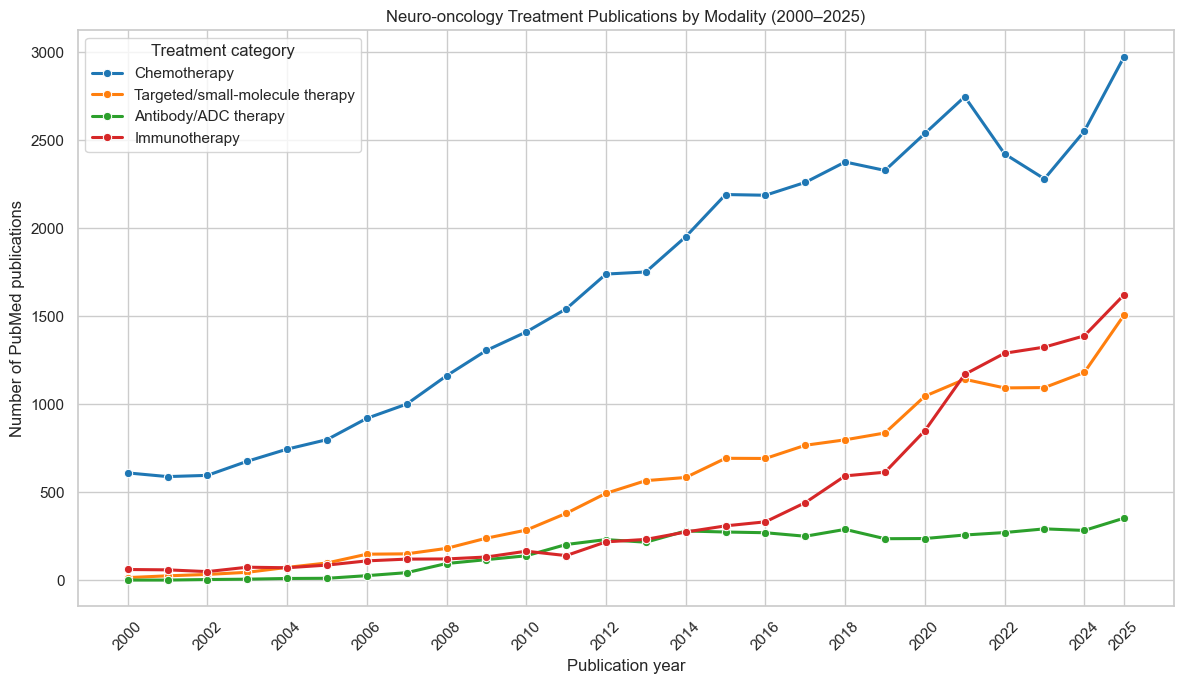

In [14]:
combined_treatment_trends = pd.concat(
    [
        chemotherapy_trend[["Year", "Publications"]].assign(Category="Chemotherapy"),
        small_molecule_trend[["Year", "Publications"]].assign(
            Category="Targeted/small-molecule therapy"
        ),
        biologic_trend[["Year", "Publications"]].assign(
            Category="Antibody/ADC therapy"
        ),
        immunotherapy_trend[["Year", "Publications"]].assign(Category="Immunotherapy"),
    ],
    ignore_index=True,
)

treatment_colors = {
    "Chemotherapy": "#1f77b4",
    "Targeted/small-molecule therapy": "#ff7f0e",
    "Antibody/ADC therapy": "#2ca02c",
    "Immunotherapy": "#d62728",
}

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=combined_treatment_trends,
    x="Year",
    y="Publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Neuro-oncology Treatment Publications by Modality (2000–2025)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of PubMed publications")
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Treatment category")
plt.tight_layout()
plt.show()

## Four treatment modalities in primary CNS tumors and CNS metastasis

The primary-CNS analysis uses the non-metastatic primary intracranial and CNS tumor terms from the neuro-oncology disease list. The CNS-metastasis analysis uses brain metastasis, brain metastases, leptomeningeal disease, and leptomeningeal carcinomatosis. Both figures show raw annual counts without rolling averages.

In [15]:
PRIMARY_CNS_DISEASE_CONTEXT = """
(
    "Glioblastoma" OR "Glioblastoma Multiforme" OR "Astrocytoma" OR "Oligodendroglioma"
    OR "Diffuse Midline Glioma" OR "H3 K27-altered" OR "Pilocytic Astrocytoma"
    OR "Pleomorphic Xanthoastrocytoma" OR "Subependymal Giant Cell Astrocytoma"
    OR "Ependymoma" OR "Myxopapillary ependymoma" OR "Ganglioglioma"
    OR "Dysembryoplastic Neuroepithelial Tumor" OR "DNET" OR "Central Neurocytoma"
    OR "Glioma" OR "DIPG" OR "Diffuse Midline Pontine Glioma" OR "Medulloblastoma"
    OR "Atypical Teratoid Rhabdoid Tumor" OR "Pineoblastoma" OR "Germinoma"
    OR "Meningioma" OR "Pituitary Adenoma" OR "Pituitary Neuroendocrine Tumor"
    OR "PNET" OR "Craniopharyngioma" OR "Vestibular Schwannoma"
    OR "Primary CNS Lymphoma" OR "Hemangioblastoma" OR "Choroid Plexus Papilloma"
)
""".strip()

CNS_METASTASIS_DISEASE_CONTEXT = """
(
    "Brain Metastasis" OR "Brain Metastases"
    OR "Leptomeningeal Disease" OR "Leptomeningeal Carcinomatosis"
)
""".strip()

CHEMOTHERAPY_THERAPY_QUERY = CHEMOTHERAPY_NEURO_ONCOLOGY_QUERY.split("\nAND\n", 1)[1]
TREATMENT_MODALITY_QUERIES = {
    "Chemotherapy": CHEMOTHERAPY_THERAPY_QUERY,
    "Targeted/small-molecule therapy": SMALL_MOLECULE_TARGETED_THERAPY_QUERY,
    "Antibody/ADC therapy": BIOLOGIC_ANTIBODY_THERAPY_QUERY,
    "Immunotherapy": IMMUNOTHERAPY_QUERY,
}

def get_context_modality_trends(context_query, start_year=2000, end_year=2025):
    frames = []
    for category, therapy_query in TREATMENT_MODALITY_QUERIES.items():
        print(f"Fetching {category} publications...")
        combined_query = f"{context_query}\nAND\n{therapy_query}"
        counts = get_pubmed_counts(combined_query, start_year, end_year)
        frames.append(pd.DataFrame({
            "Year": range(start_year, end_year + 1),
            "Publications": counts,
            "Category": category,
        }))
    return pd.concat(frames, ignore_index=True)

print("Fetching primary CNS tumor trends by treatment modality...")
primary_cns_treatment_trends = get_context_modality_trends(PRIMARY_CNS_DISEASE_CONTEXT)

Fetching primary CNS tumor trends by treatment modality...
Fetching Chemotherapy publications...


Fetching Targeted/small-molecule therapy publications...


Fetching Antibody/ADC therapy publications...


Fetching Immunotherapy publications...


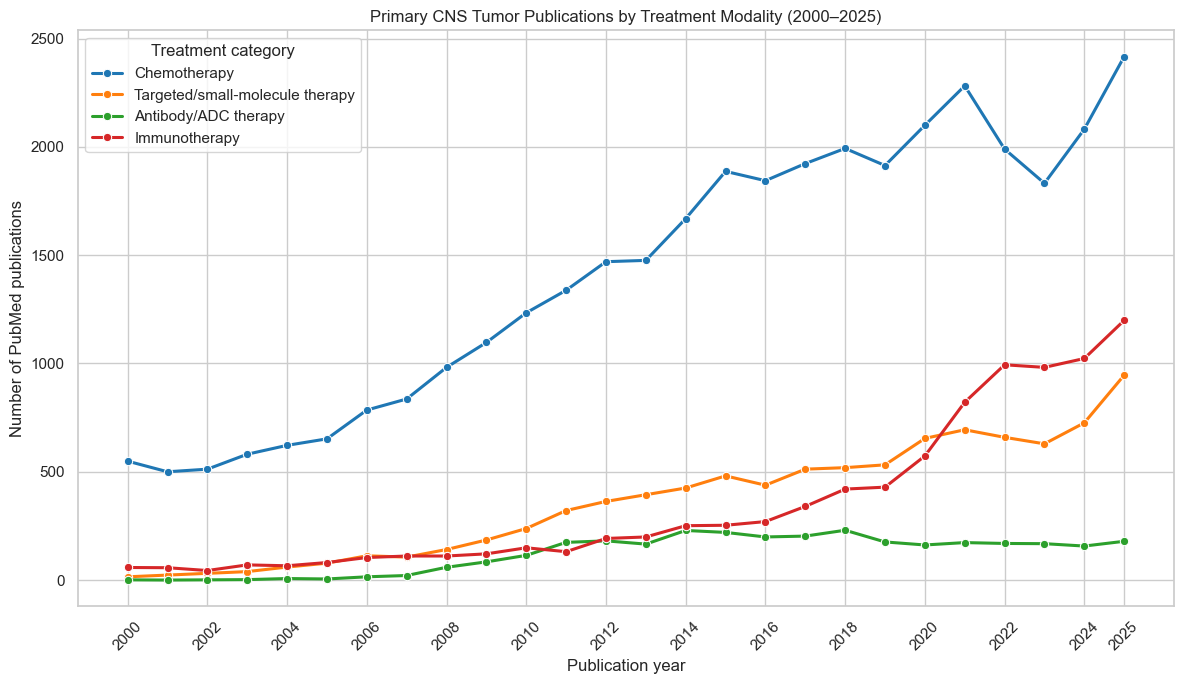

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=primary_cns_treatment_trends,
    x="Year",
    y="Publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Primary CNS Tumor Publications by Treatment Modality (2000–2025)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of PubMed publications")
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Treatment category")
plt.tight_layout()
plt.show()

In [17]:
print("Fetching CNS metastasis trends by treatment modality...")
cns_metastasis_treatment_trends = get_context_modality_trends(CNS_METASTASIS_DISEASE_CONTEXT)

Fetching CNS metastasis trends by treatment modality...
Fetching Chemotherapy publications...


Fetching Targeted/small-molecule therapy publications...


Fetching Antibody/ADC therapy publications...


Fetching Immunotherapy publications...


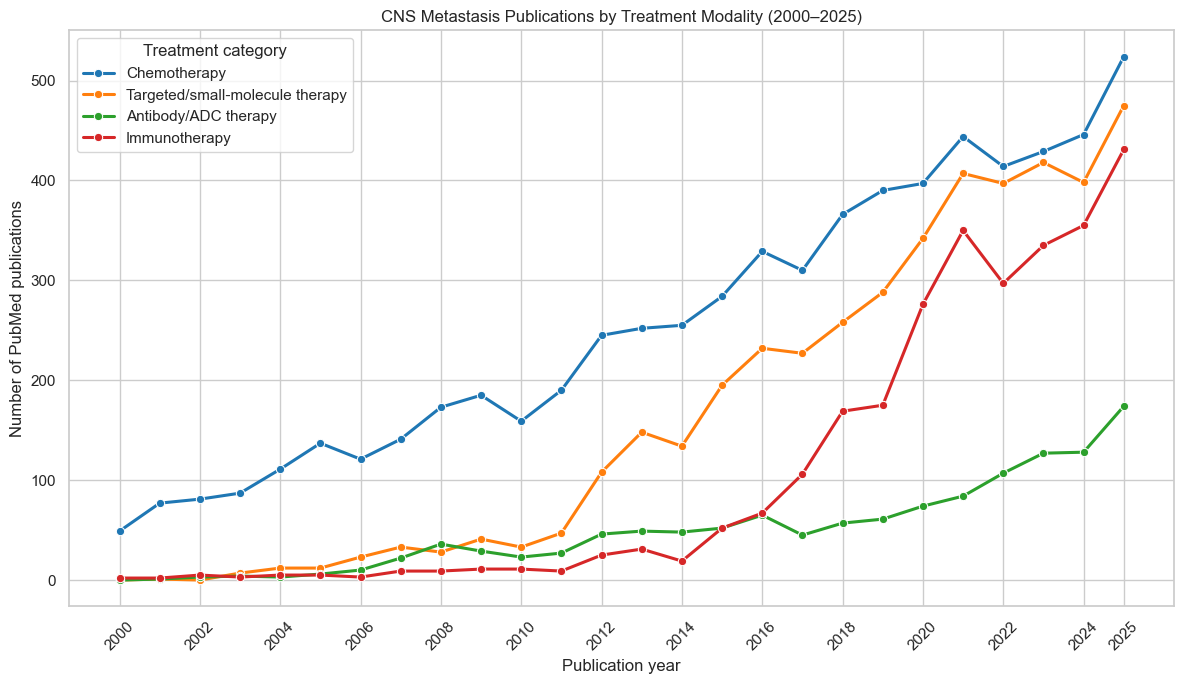

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=cns_metastasis_treatment_trends,
    x="Year",
    y="Publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("CNS Metastasis Publications by Treatment Modality (2000–2025)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of PubMed publications")
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Treatment category")
plt.tight_layout()
plt.show()

## Phase III trial publications by treatment modality, 2000–2025

These three integrated figures apply the phase III publication-type/title-abstract criterion to the overall neuro-oncology, primary-CNS, and CNS-metastasis contexts. They show raw annual counts without rolling averages.

In [19]:
PHASE_III_CRITERIA = """
(
    "Clinical Trial, Phase III"[Publication Type]
    OR "phase III"[Title/Abstract]
    OR "phase 3"[Title/Abstract]
)
""".strip()

def get_phase_iii_context_modality_trends(context_query, start_year=2000, end_year=2025):
    frames = []
    for category, therapy_query in TREATMENT_MODALITY_QUERIES.items():
        print(f"Fetching phase III {category} publications...")
        combined_query = (
            f"{context_query}\nAND\n{therapy_query}\nAND\n{PHASE_III_CRITERIA}"
        )
        counts = get_pubmed_counts(combined_query, start_year, end_year)
        frames.append(pd.DataFrame({
            "Year": range(start_year, end_year + 1),
            "Publications": counts,
            "Category": category,
        }))
    return pd.concat(frames, ignore_index=True)

print("Fetching overall neuro-oncology phase III trends by treatment modality...")
phase_iii_overall_trends = get_phase_iii_context_modality_trends(
    NEURO_ONCOLOGY_DISEASE_CONTEXT
)

Fetching overall neuro-oncology phase III trends by treatment modality...
Fetching phase III Chemotherapy publications...


Fetching phase III Targeted/small-molecule therapy publications...


Fetching phase III Antibody/ADC therapy publications...


Fetching phase III Immunotherapy publications...


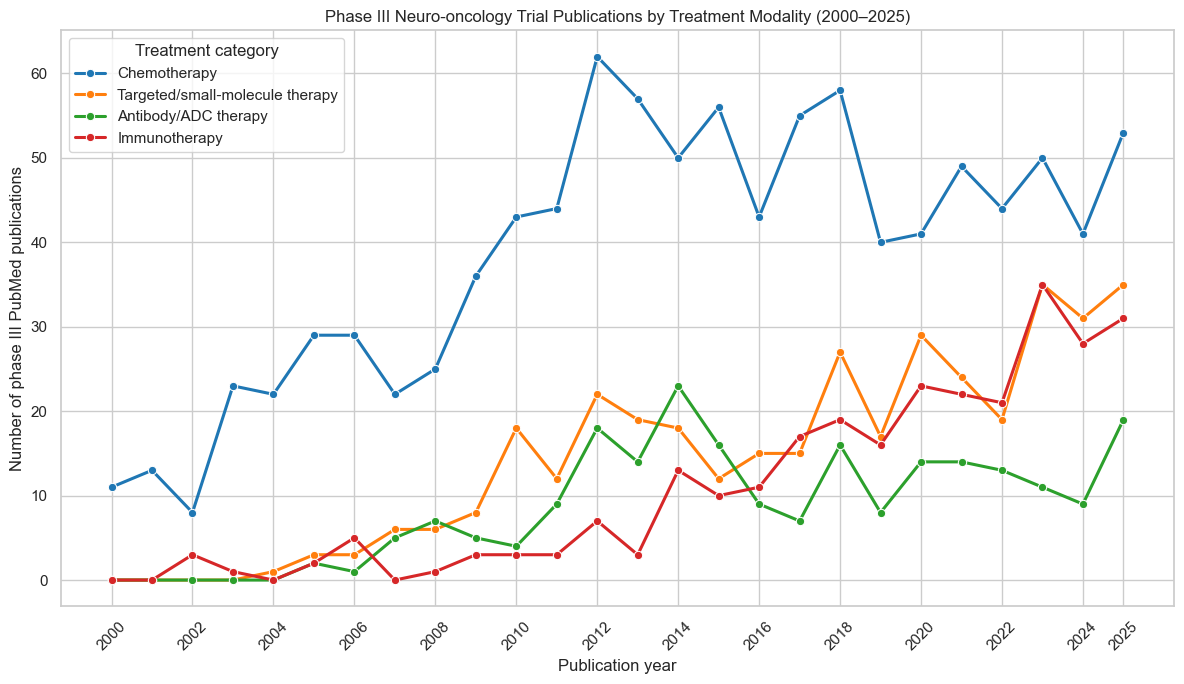

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=phase_iii_overall_trends,
    x="Year",
    y="Publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Phase III Neuro-oncology Trial Publications by Treatment Modality (2000–2025)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of phase III PubMed publications")
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Treatment category")
plt.tight_layout()
plt.show()

In [21]:
print("Fetching primary CNS tumor phase III trends by treatment modality...")
phase_iii_primary_cns_trends = get_phase_iii_context_modality_trends(
    PRIMARY_CNS_DISEASE_CONTEXT
)

Fetching primary CNS tumor phase III trends by treatment modality...
Fetching phase III Chemotherapy publications...


Fetching phase III Targeted/small-molecule therapy publications...


Fetching phase III Antibody/ADC therapy publications...


Fetching phase III Immunotherapy publications...


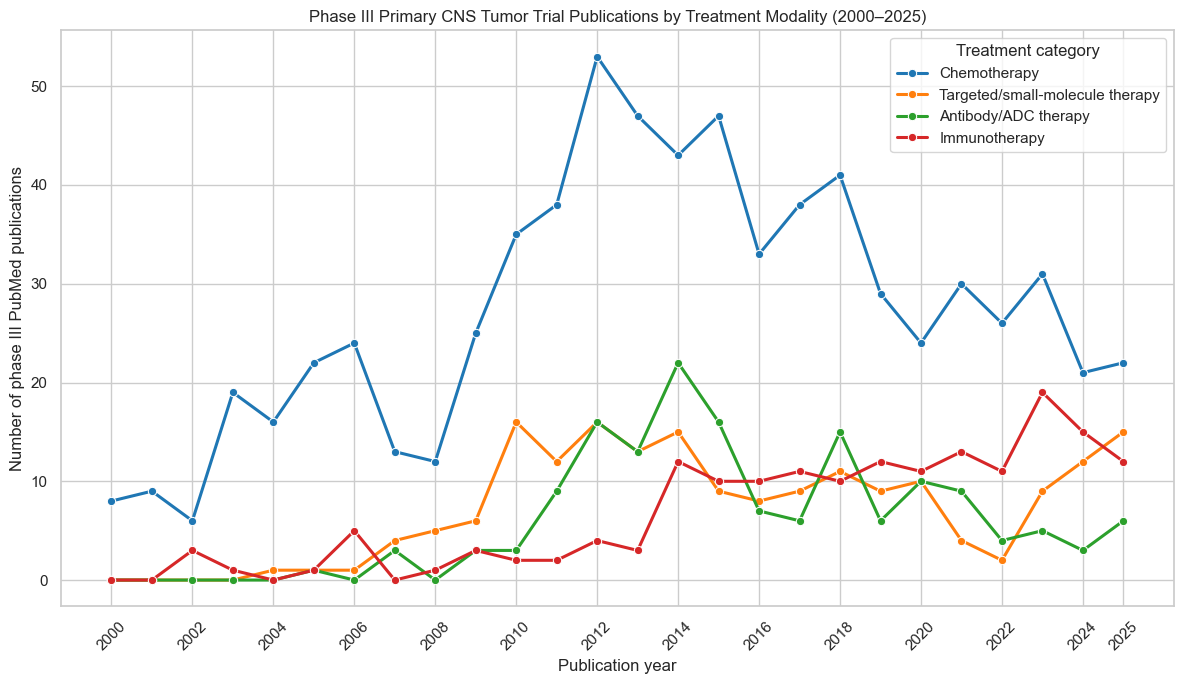

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=phase_iii_primary_cns_trends,
    x="Year",
    y="Publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Phase III Primary CNS Tumor Trial Publications by Treatment Modality (2000–2025)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of phase III PubMed publications")
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Treatment category")
plt.tight_layout()
plt.show()

In [23]:
print("Fetching CNS metastasis phase III trends by treatment modality...")
phase_iii_cns_metastasis_trends = get_phase_iii_context_modality_trends(
    CNS_METASTASIS_DISEASE_CONTEXT
)

Fetching CNS metastasis phase III trends by treatment modality...
Fetching phase III Chemotherapy publications...


Fetching phase III Targeted/small-molecule therapy publications...


Fetching phase III Antibody/ADC therapy publications...


Fetching phase III Immunotherapy publications...


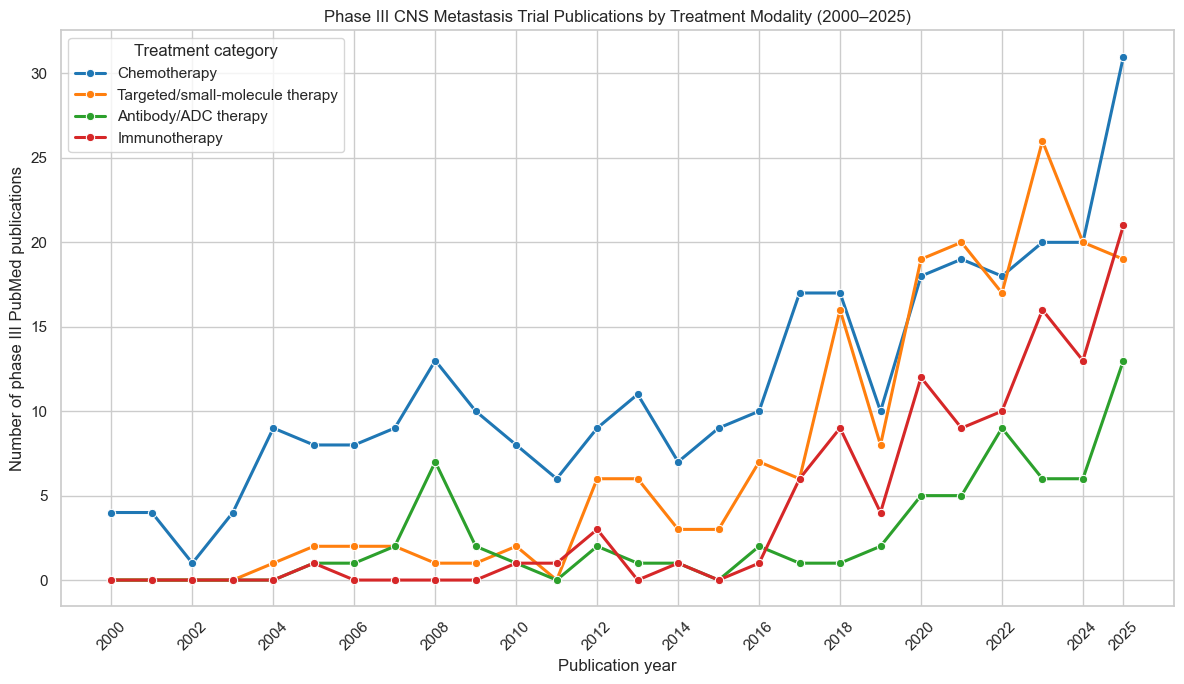

In [24]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=phase_iii_cns_metastasis_trends,
    x="Year",
    y="Publications",
    hue="Category",
    palette=treatment_colors,
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Phase III CNS Metastasis Trial Publications by Treatment Modality (2000–2025)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of phase III PubMed publications")
ax.set_xticks([*range(2000, 2025, 2), 2025])
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Treatment category")
plt.tight_layout()
plt.show()